<a href="https://colab.research.google.com/github/isabeljimenezalcantara/Clinical-Data-Science-Portfolio/blob/main/Proyecto_1_PERG_EDA/notebooks/EDA_PERG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1: Exploratory Data Analysis of PERG-IOBA Dataset

**Author:** Isabel Jimenez Alcantara  
**Date:** 2026-04-06  

## Objective
Perform a clean, reproducible exploratory data analysis (EDA) of the PERG-IOBA dataset to identify clinical patterns in ocular conditions.  

The notebook includes:  
- Data loading from the PhysioNet URL  
- Cleaning and inspection  
- Visualizations for demographics, diagnoses, and clinical variables  
- Summary tables  
- Functions for reusable plotting

Step 0: Setup Environment

Purpose:

Import necessary libraries for data handling, visualization, and analysis.
Configure plotting style for clarity.
Create folders for saving figures, scripts, and processed data.
Save reusable plotting functions to a script for efficient workflow

In [17]:
# Step 0: Setup Environment
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plotting style
sns.set(style="whitegrid")
%matplotlib inline

# Create folders
os.makedirs("data", exist_ok=True)
os.makedirs("figures", exist_ok=True)
os.makedirs("scripts", exist_ok=True)

# Create reusable plotting script
eda_script = """
import matplotlib.pyplot as plt
import seaborn as sns

def plot_hist(df, col, save_path=None, title=None):
    plt.figure(figsize=(8,5))
    sns.histplot(df[col], bins=15, kde=True)
    if title: plt.title(title)
    plt.xlabel(col)
    plt.ylabel("Count")
    if save_path: plt.savefig(save_path)
    plt.show()

def plot_box(df, x_col, y_col, save_path=None, title=None):
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df, x=x_col, y=y_col)
    if title: plt.title(title)
    if save_path: plt.savefig(save_path)
    plt.show()

def plot_count(df, x_col, y_col=None, hue=None, save_path=None, title=None):
    plt.figure(figsize=(10,6))
    if y_col:
        sns.countplot(data=df, y=y_col, x=x_col, hue=hue, order=df[y_col].value_counts().index)
    else:
        sns.countplot(data=df, x=x_col, hue=hue)
    if title: plt.title(title)
    if save_path: plt.savefig(save_path)
    plt.show()
"""

with open("scripts/eda_functions.py", "w") as f:
    f.write(eda_script)

Step 1: Load Dataset from URL and Save Clean Copy

Purpose:

Load the PERG-IOBA participants dataset directly from PhysioNet for reproducibility.
Inspect the initial rows to understand structure.
Save a clean copy to data/ for later use and GitHub.

In [18]:
# Create data folder if it doesn't exist
os.makedirs("data", exist_ok=True)

# URL of participants CSV
participants_url = "https://physionet.org/files/perg-ioba-dataset/1.0.0/csv/participants_info.csv"

# Load data into pandas DataFrame
participants_df = pd.read_csv(participants_url)

# Preview first rows
participants_df.head()

# Save a cleaned copy to data/ for reproducibility
participants_df.to_csv("data/participants_info_clean.csv", index=False)

# Optional: verify saved file
check_df = pd.read_csv("data/participants_info_clean.csv")
check_df.head()

,id_record,date,age_years,sex,diagnosis1,diagnosis2,diagnosis3,va_re_logMar,va_le_logMar,unilateral,rep_record,comments
0,1,2016-09-15,13,Male,Normal,NaN,NaN,-0.08,0.06,NaN,NaN,NaN
1,2,2005-09-15,13,Female,Congenital stationary night blindness,NaN,NaN,0.18,0.16,NaN,NaN,NaN
2,3,2019-08-08,49,Female,Orbital ischemia,Systemic disorder with ocular manifestations,NaN,0.26,0.00,NaN,Id:0329 - Id:0154 - Id:0049 - Id:0271,NaN
3,4,2004-12-16,43,Female,Retinitis pigmentosa,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2016-07-13,47,Female,Normal,NaN,NaN,0.10,0.10,NaN,NaN,NaN


Step 2: Initial Data Inspection

Purpose:

Check column names, data types, and missing values
Inspect basic descriptive statistics
Identify potential issues that may require cleaning or preprocessing

In [19]:
# Basic info
participants_df.info()

# Missing values
participants_df.isnull().sum()

# Descriptive statistics
participants_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_record     336 non-null    int64  
 1   date          336 non-null    object 
 2   age_years     336 non-null    int64  
 3   sex           336 non-null    object 
 4   diagnosis1    336 non-null    object 
 5   diagnosis2    90 non-null     object 
 6   diagnosis3    13 non-null     object 
 7   va_re_logMar  317 non-null    float64
 8   va_le_logMar  317 non-null    float64
 9   unilateral    8 non-null      object 
 10  rep_record    55 non-null     object 
 11  comments      95 non-null     object 
dtypes: float64(2), int64(2), object(8)
memory usage: 31.6+ KB


,id_record,age_years,va_re_logMar,va_le_logMar
count,336.000000,336.000000,317.000000,317.000000
mean,168.500000,37.071429,0.339464,0.320126
std,97.139076,18.284182,0.546977,0.501910
min,1.000000,4.000000,-0.100000,-0.100000
25%,84.750000,21.000000,0.000000,0.000000
50%,168.500000,38.000000,0.160000,0.140000
75%,252.250000,51.000000,0.500000,0.480000
max,336.000000,86.000000,3.000000,3.000000


Step 3: Explore Basic Demographics

Purpose:

Visualize distribution of participants by sex
Explore age distribution
Understand sample characteristics to provide clinical context

Methods:

Bar plot for sex distribution
Histogram for age distribution

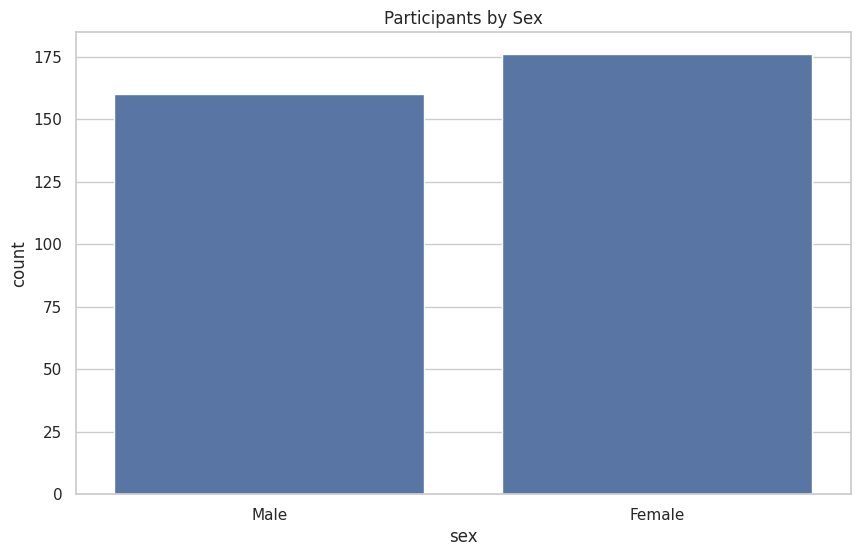

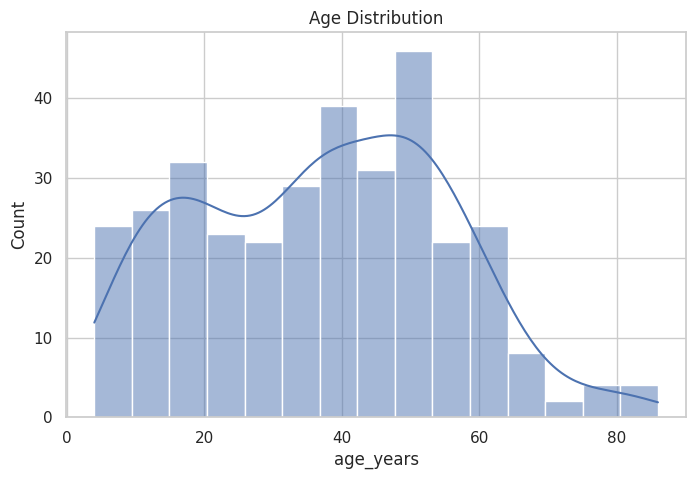

In [20]:
from scripts.eda_functions import plot_hist, plot_count

# Count by sex
plot_count(participants_df, x_col='sex', title="Participants by Sex", save_path="figures/participants_by_sex.png")

# Age distribution
plot_hist(participants_df, col='age_years', title="Age Distribution", save_path="figures/age_distribution.png")

Step 4: Explore Top Diagnoses and Subpopulations

Purpose:

Identify the 10 most frequent primary diagnoses
Explore demographic and clinical differences across diagnoses
Visualize age and right-eye visual acuity distributions by diagnosis

Methods:

Horizontal bar plot for top 10 diagnoses
Boxplots for age and right-eye visual acuity by diagnosis

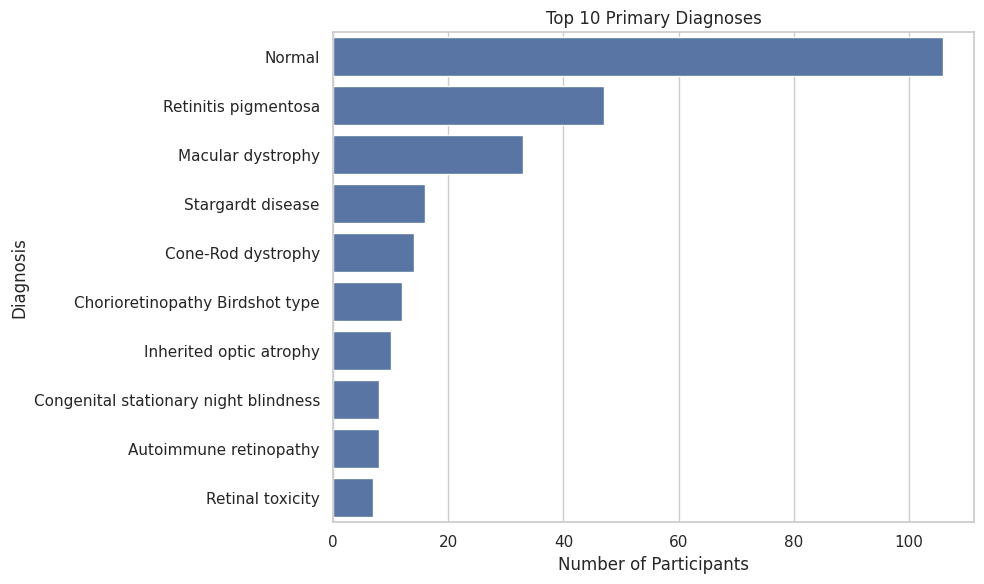

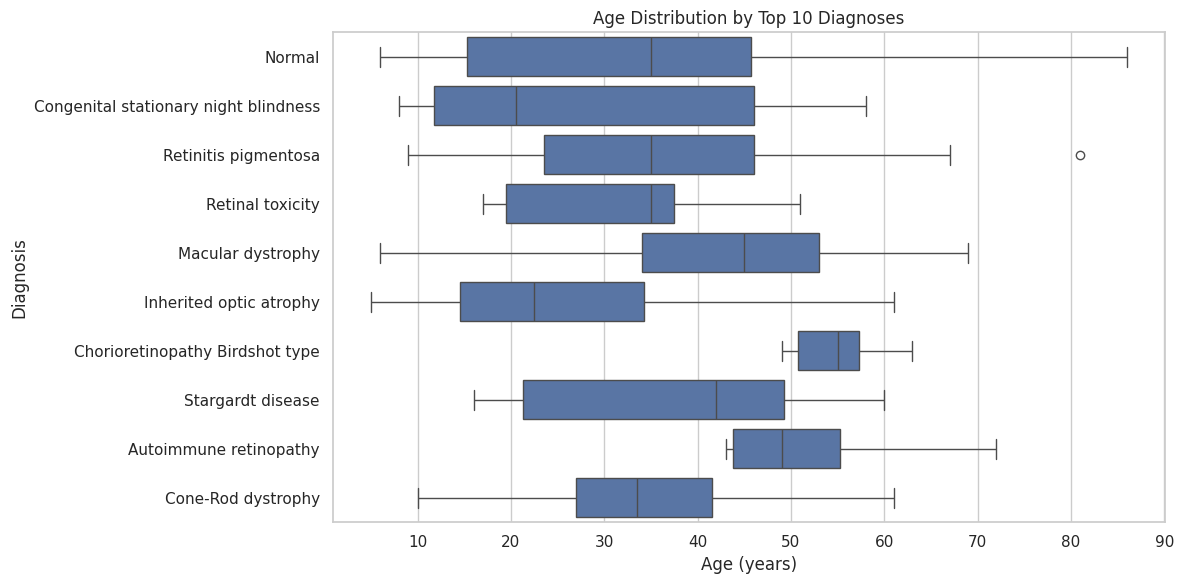

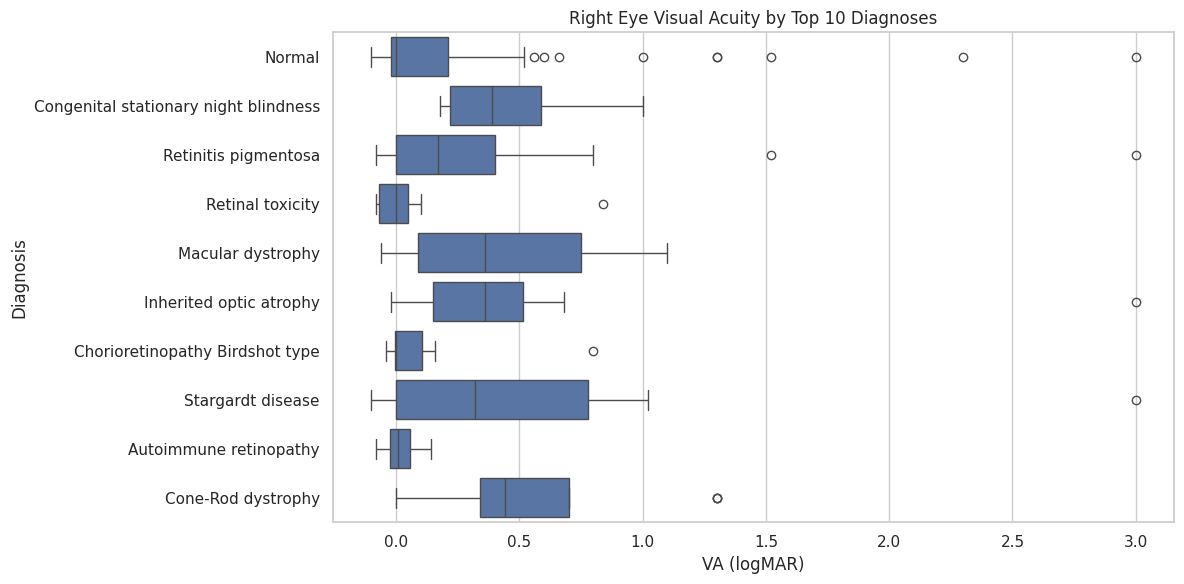

In [21]:
# Top 10 primary diagnoses
top_diag = participants_df['diagnosis1'].value_counts().nlargest(10).index
df_top_diag = participants_df[participants_df['diagnosis1'].isin(top_diag)]

# Horizontal barplot
plt.figure(figsize=(10,6))
sns.countplot(data=df_top_diag, y='diagnosis1', order=df_top_diag['diagnosis1'].value_counts().index)
plt.title("Top 10 Primary Diagnoses")
plt.xlabel("Number of Participants")
plt.ylabel("Diagnosis")
plt.tight_layout()
plt.savefig("figures/top10_diagnoses.png")
plt.show()

# Age distribution by diagnosis
plt.figure(figsize=(12,6))
sns.boxplot(data=df_top_diag, y='diagnosis1', x='age_years')
plt.title("Age Distribution by Top 10 Diagnoses")
plt.xlabel("Age (years)")
plt.ylabel("Diagnosis")
plt.tight_layout()
plt.savefig("figures/age_by_top10_diagnoses.png")
plt.show()

# Right eye visual acuity by diagnosis
plt.figure(figsize=(12,6))
sns.boxplot(data=df_top_diag, y='diagnosis1', x='va_re_logMar')
plt.title("Right Eye Visual Acuity by Top 10 Diagnoses")
plt.xlabel("VA (logMAR)")
plt.ylabel("Diagnosis")
plt.tight_layout()
plt.savefig("figures/va_re_by_top10_diagnoses.png")
plt.show()